Problem Statement: 

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv(r"C:\Machine_learning_Projects\01_medical_insurance_cost_prediction\medical_insurance.csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [21]:
df.shape

(100000, 54)

In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [23]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [24]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


In [25]:
df.isnull().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [26]:
df["alcohol_freq"].isnull().mean() * 100

np.float64(30.083)

The alcohol freq col have approximately 30 percent null values so we will be handling that data like this :

In [27]:
df["alcohol_freq"] = df["alcohol_freq"].fillna("Unknown")

In [28]:
df.isnull().sum()

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

In [30]:
df = df.drop(columns=['person_id'])#dropped the column id

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  str    
 2   region                       100000 non-null  str    
 3   urban_rural                  100000 non-null  str    
 4   income                       100000 non-null  float64
 5   education                    100000 non-null  str    
 6   marital_status               100000 non-null  str    
 7   employment_status            100000 non-null  str    
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  str    
 12  alcohol_freq                 100000 non-null  str    
 13  visits_last

Now lets encode and map our data

In [32]:
df['sex'].value_counts()

sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64

In [33]:
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

In [34]:
df.head()

,age,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,...,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,sex_Male,sex_Other
0,52,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,...,0,1,0,2,0,1,0,0,False,False
1,79,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,...,1,0,0,1,0,1,1,0,False,False
2,68,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,...,1,1,0,2,1,0,1,0,True,False
3,15,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,...,0,1,0,0,1,0,0,0,True,False
4,53,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,...,0,2,0,1,1,0,1,0,True,False


In [36]:
df['region'].value_counts()

region
South      28029
North      22027
East       19984
West       17879
Central    12081
Name: count, dtype: int64

In [37]:
df = pd.get_dummies(df, columns=['region'],drop_first='True')

In [38]:
df.head()

,age,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,...,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,sex_Male,sex_Other,region_East,region_North,region_South,region_West
0,52,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,...,0,1,0,0,False,False,False,True,False,False
1,79,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,...,0,1,1,0,False,False,False,True,False,False
2,68,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,...,1,0,1,0,True,False,False,True,False,False
3,15,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,...,1,0,0,0,True,False,False,True,False,False
4,53,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,...,1,0,1,0,True,False,False,False,False,False


In [39]:
df['urban_rural'].value_counts()

urban_rural
Urban       60019
Suburban    25021
Rural       14960
Name: count, dtype: int64

In [41]:
df = pd.get_dummies(df,columns = ['urban_rural'],drop_first = 'True')

In [42]:
df.head()

,age,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,...,is_high_risk,had_major_procedure,sex_Male,sex_Other,region_East,region_North,region_South,region_West,urban_rural_Suburban,urban_rural_Urban
0,52,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Unknown,...,0,0,False,False,False,True,False,False,True,False
1,79,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,...,1,0,False,False,False,True,False,False,False,True
2,68,40700.0,HS,Married,Retired,5,3,31.5,Never,Unknown,...,1,0,True,False,False,True,False,False,False,False
3,15,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,Unknown,...,0,0,True,False,False,True,False,False,True,False
4,53,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,...,1,0,True,False,False,False,False,False,True,False


In [43]:
df['education'].value_counts()

education
Bachelors       27996
Some College    25112
HS              24827
Masters         13987
No HS            5120
Doctorate        2958
Name: count, dtype: int64

In [44]:
df = pd.get_dummies(df,columns=['education'],drop_first="True")

In [45]:
df.head()

,age,income,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,...,region_North,region_South,region_West,urban_rural_Suburban,urban_rural_Urban,education_Doctorate,education_HS,education_Masters,education_No HS,education_Some College
0,52,22700.0,Married,Retired,3,1,27.4,Never,Unknown,2,...,True,False,False,True,False,True,False,False,False,False
1,79,12800.0,Married,Employed,3,1,26.6,Never,Weekly,2,...,True,False,False,False,True,False,False,False,True,False
2,68,40700.0,Married,Retired,5,3,31.5,Never,Unknown,1,...,True,False,False,False,False,False,True,False,False,False
3,15,15600.0,Married,Self-employed,5,3,31.6,Never,Unknown,0,...,True,False,False,True,False,False,False,False,False,True
4,53,89600.0,Married,Self-employed,2,0,30.5,Never,Daily,3,...,False,False,False,True,False,True,False,False,False,False


In [46]:
df['marital_status'].value_counts()

marital_status
Married     53252
Single      35715
Divorced     6984
Widowed      4049
Name: count, dtype: int64

In [47]:
df = pd.get_dummies(df,columns=['marital_status'],drop_first="True")

In [48]:
df.head()

,age,income,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,...,urban_rural_Suburban,urban_rural_Urban,education_Doctorate,education_HS,education_Masters,education_No HS,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed
0,52,22700.0,Retired,3,1,27.4,Never,Unknown,2,0,...,True,False,True,False,False,False,False,True,False,False
1,79,12800.0,Employed,3,1,26.6,Never,Weekly,2,0,...,False,True,False,False,False,True,False,True,False,False
2,68,40700.0,Retired,5,3,31.5,Never,Unknown,1,0,...,False,False,False,True,False,False,False,True,False,False
3,15,15600.0,Self-employed,5,3,31.6,Never,Unknown,0,0,...,True,False,False,False,False,False,True,True,False,False
4,53,89600.0,Self-employed,2,0,30.5,Never,Daily,3,0,...,True,False,True,False,False,False,False,True,False,False


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 64 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   income                       100000 non-null  float64
 2   employment_status            100000 non-null  str    
 3   household_size               100000 non-null  int64  
 4   dependents                   100000 non-null  int64  
 5   bmi                          100000 non-null  float64
 6   smoker                       100000 non-null  str    
 7   alcohol_freq                 100000 non-null  str    
 8   visits_last_year             100000 non-null  int64  
 9   hospitalizations_last_3yrs   100000 non-null  int64  
 10  days_hospitalized_last_3yrs  100000 non-null  int64  
 11  medication_count             100000 non-null  int64  
 12  systolic_bp                  100000 non-null  float64
 13  diastolic_b

In [50]:
df['employment_status'].value_counts()

employment_status
Employed         55269
Retired          19864
Unemployed       12939
Self-employed    11928
Name: count, dtype: int64

In [51]:
df = pd.get_dummies(df,columns=['employment_status'],drop_first="True")

In [53]:
df.head()

,age,income,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,...,education_HS,education_Masters,education_No HS,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed
0,52,22700.0,3,1,27.4,Never,Unknown,2,0,0,...,False,False,False,False,True,False,False,True,False,False
1,79,12800.0,3,1,26.6,Never,Weekly,2,0,0,...,False,False,True,False,True,False,False,False,False,False
2,68,40700.0,5,3,31.5,Never,Unknown,1,0,0,...,True,False,False,False,True,False,False,True,False,False
3,15,15600.0,5,3,31.6,Never,Unknown,0,0,0,...,False,False,False,True,True,False,False,False,True,False
4,53,89600.0,2,0,30.5,Never,Daily,3,0,0,...,False,False,False,False,True,False,False,False,True,False


In [54]:
df['smoker'].value_counts()

smoker
Never      69709
Former     18163
Current    12128
Name: count, dtype: int64

In [55]:
df["smoker"] = df["smoker"].map({'Never':0,'Former':1,'Current':2})

In [56]:
df.head()

,age,income,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,...,education_HS,education_Masters,education_No HS,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed
0,52,22700.0,3,1,27.4,0,Unknown,2,0,0,...,False,False,False,False,True,False,False,True,False,False
1,79,12800.0,3,1,26.6,0,Weekly,2,0,0,...,False,False,True,False,True,False,False,False,False,False
2,68,40700.0,5,3,31.5,0,Unknown,1,0,0,...,True,False,False,False,True,False,False,True,False,False
3,15,15600.0,5,3,31.6,0,Unknown,0,0,0,...,False,False,False,True,True,False,False,False,True,False
4,53,89600.0,2,0,30.5,0,Daily,3,0,0,...,False,False,False,False,True,False,False,False,True,False


In [58]:
df['alcohol_freq'].value_counts()

alcohol_freq
Occasional    45078
Unknown       30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

In [59]:
df = pd.get_dummies(df, columns=['alcohol_freq'], drop_first=True)

In [60]:
df.head()

,age,income,household_size,dependents,bmi,smoker,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,education_Some College,marital_status_Married,marital_status_Single,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly
0,52,22700.0,3,1,27.4,0,2,0,0,4,...,False,True,False,False,True,False,False,False,True,False
1,79,12800.0,3,1,26.6,0,2,0,0,3,...,False,True,False,False,False,False,False,False,False,True
2,68,40700.0,5,3,31.5,0,1,0,0,4,...,False,True,False,False,True,False,False,False,True,False
3,15,15600.0,5,3,31.6,0,0,0,0,1,...,True,True,False,False,False,True,False,False,True,False
4,53,89600.0,2,0,30.5,0,3,0,0,2,...,False,True,False,False,False,True,False,False,False,False


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 68 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              100000 non-null  int64  
 1   income                           100000 non-null  float64
 2   household_size                   100000 non-null  int64  
 3   dependents                       100000 non-null  int64  
 4   bmi                              100000 non-null  float64
 5   smoker                           100000 non-null  int64  
 6   visits_last_year                 100000 non-null  int64  
 7   hospitalizations_last_3yrs       100000 non-null  int64  
 8   days_hospitalized_last_3yrs      100000 non-null  int64  
 9   medication_count                 100000 non-null  int64  
 10  systolic_bp                      100000 non-null  float64
 11  diastolic_bp                     100000 non-null  float64
 12  ldl           

In [62]:
df['plan_type'].value_counts()

plan_type
PPO    35167
HMO    34723
EPO    15121
POS    14989
Name: count, dtype: int64

In [63]:
df = pd.get_dummies(df,columns=['plan_type'],drop_first="True")

In [64]:
df.head()

,age,income,household_size,dependents,bmi,smoker,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,marital_status_Widowed,employment_status_Retired,employment_status_Self-employed,employment_status_Unemployed,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly,plan_type_HMO,plan_type_POS,plan_type_PPO
0,52,22700.0,3,1,27.4,0,2,0,0,4,...,False,True,False,False,False,True,False,False,False,True
1,79,12800.0,3,1,26.6,0,2,0,0,3,...,False,False,False,False,False,False,True,False,True,False
2,68,40700.0,5,3,31.5,0,1,0,0,4,...,False,True,False,False,False,True,False,True,False,False
3,15,15600.0,5,3,31.6,0,0,0,0,1,...,False,False,True,False,False,True,False,True,False,False
4,53,89600.0,2,0,30.5,0,3,0,0,2,...,False,False,True,False,False,False,False,False,True,False


In [65]:
df['network_tier'].value_counts()

network_tier
Silver      40177
Bronze      29932
Gold        19882
Platinum    10009
Name: count, dtype: int64

In [66]:
df["network_tier"] = df["network_tier"].map({"Bronze": 0,"Silver": 1,"Gold": 2,"Platinum": 3})

In [69]:
df['network_tier'].value_counts()

network_tier
1    40177
0    29932
2    19882
3    10009
Name: count, dtype: int64

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   age                              100000 non-null  int64  
 1   income                           100000 non-null  float64
 2   household_size                   100000 non-null  int64  
 3   dependents                       100000 non-null  int64  
 4   bmi                              100000 non-null  float64
 5   smoker                           100000 non-null  int64  
 6   visits_last_year                 100000 non-null  int64  
 7   hospitalizations_last_3yrs       100000 non-null  int64  
 8   days_hospitalized_last_3yrs      100000 non-null  int64  
 9   medication_count                 100000 non-null  int64  
 10  systolic_bp                      100000 non-null  float64
 11  diastolic_bp                     100000 non-null  float64
 12  ldl           

In [ ]:
df.duplicated().sum()#No duplicate values

np.int64(0)

Now lets start Visualization

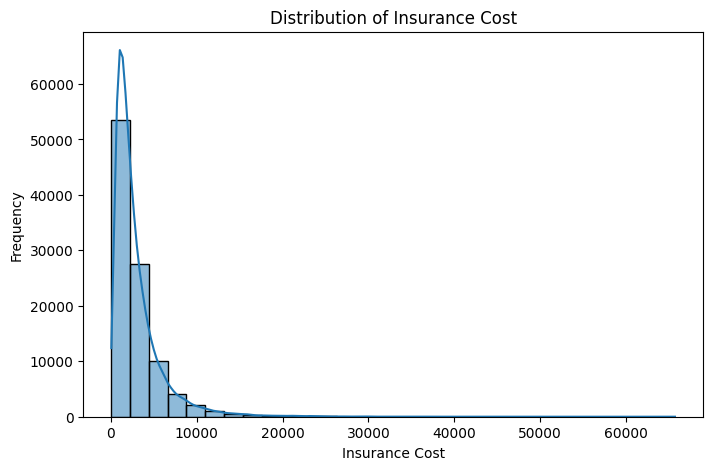

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(df["annual_medical_cost"], bins=30, kde=True)
plt.title("Distribution of Insurance Cost")
plt.xlabel("Insurance Cost")
plt.ylabel("Frequency")
plt.show()

The target variable (insurance_cost) is positively (right) skewed. Most policyholders have relatively low insurance costs, while a small number have significantly higher costs, resulting in a long right tail. The distribution is not normal, indicating the presence of high-cost cases that may influence the regression model.

In [76]:
df.columns

Index(['age', 'income', 'household_size', 'dependents', 'bmi', 'smoker',
       'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'hba1c', 'network_tier', 'deductible', 'copay',
       'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
       'risk_score', 'annual_medical_cost', 'annual_premium',
       'monthly_premium', 'claims_count', 'avg_claim_amount',
       'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes',
       'asthma', 'copd', 'cardiovascular_disease', 'cancer_history',
       'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',
       'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
       'proc_consult_count', 'proc_lab_count', 'is_high_risk',
       'had_major_procedure', 'sex_Male', 'sex_Other', 'region_East',
       'region_North', 'region_South', 'region_West', 'urban_rural_Suburban',
       'urban_rural_Ur

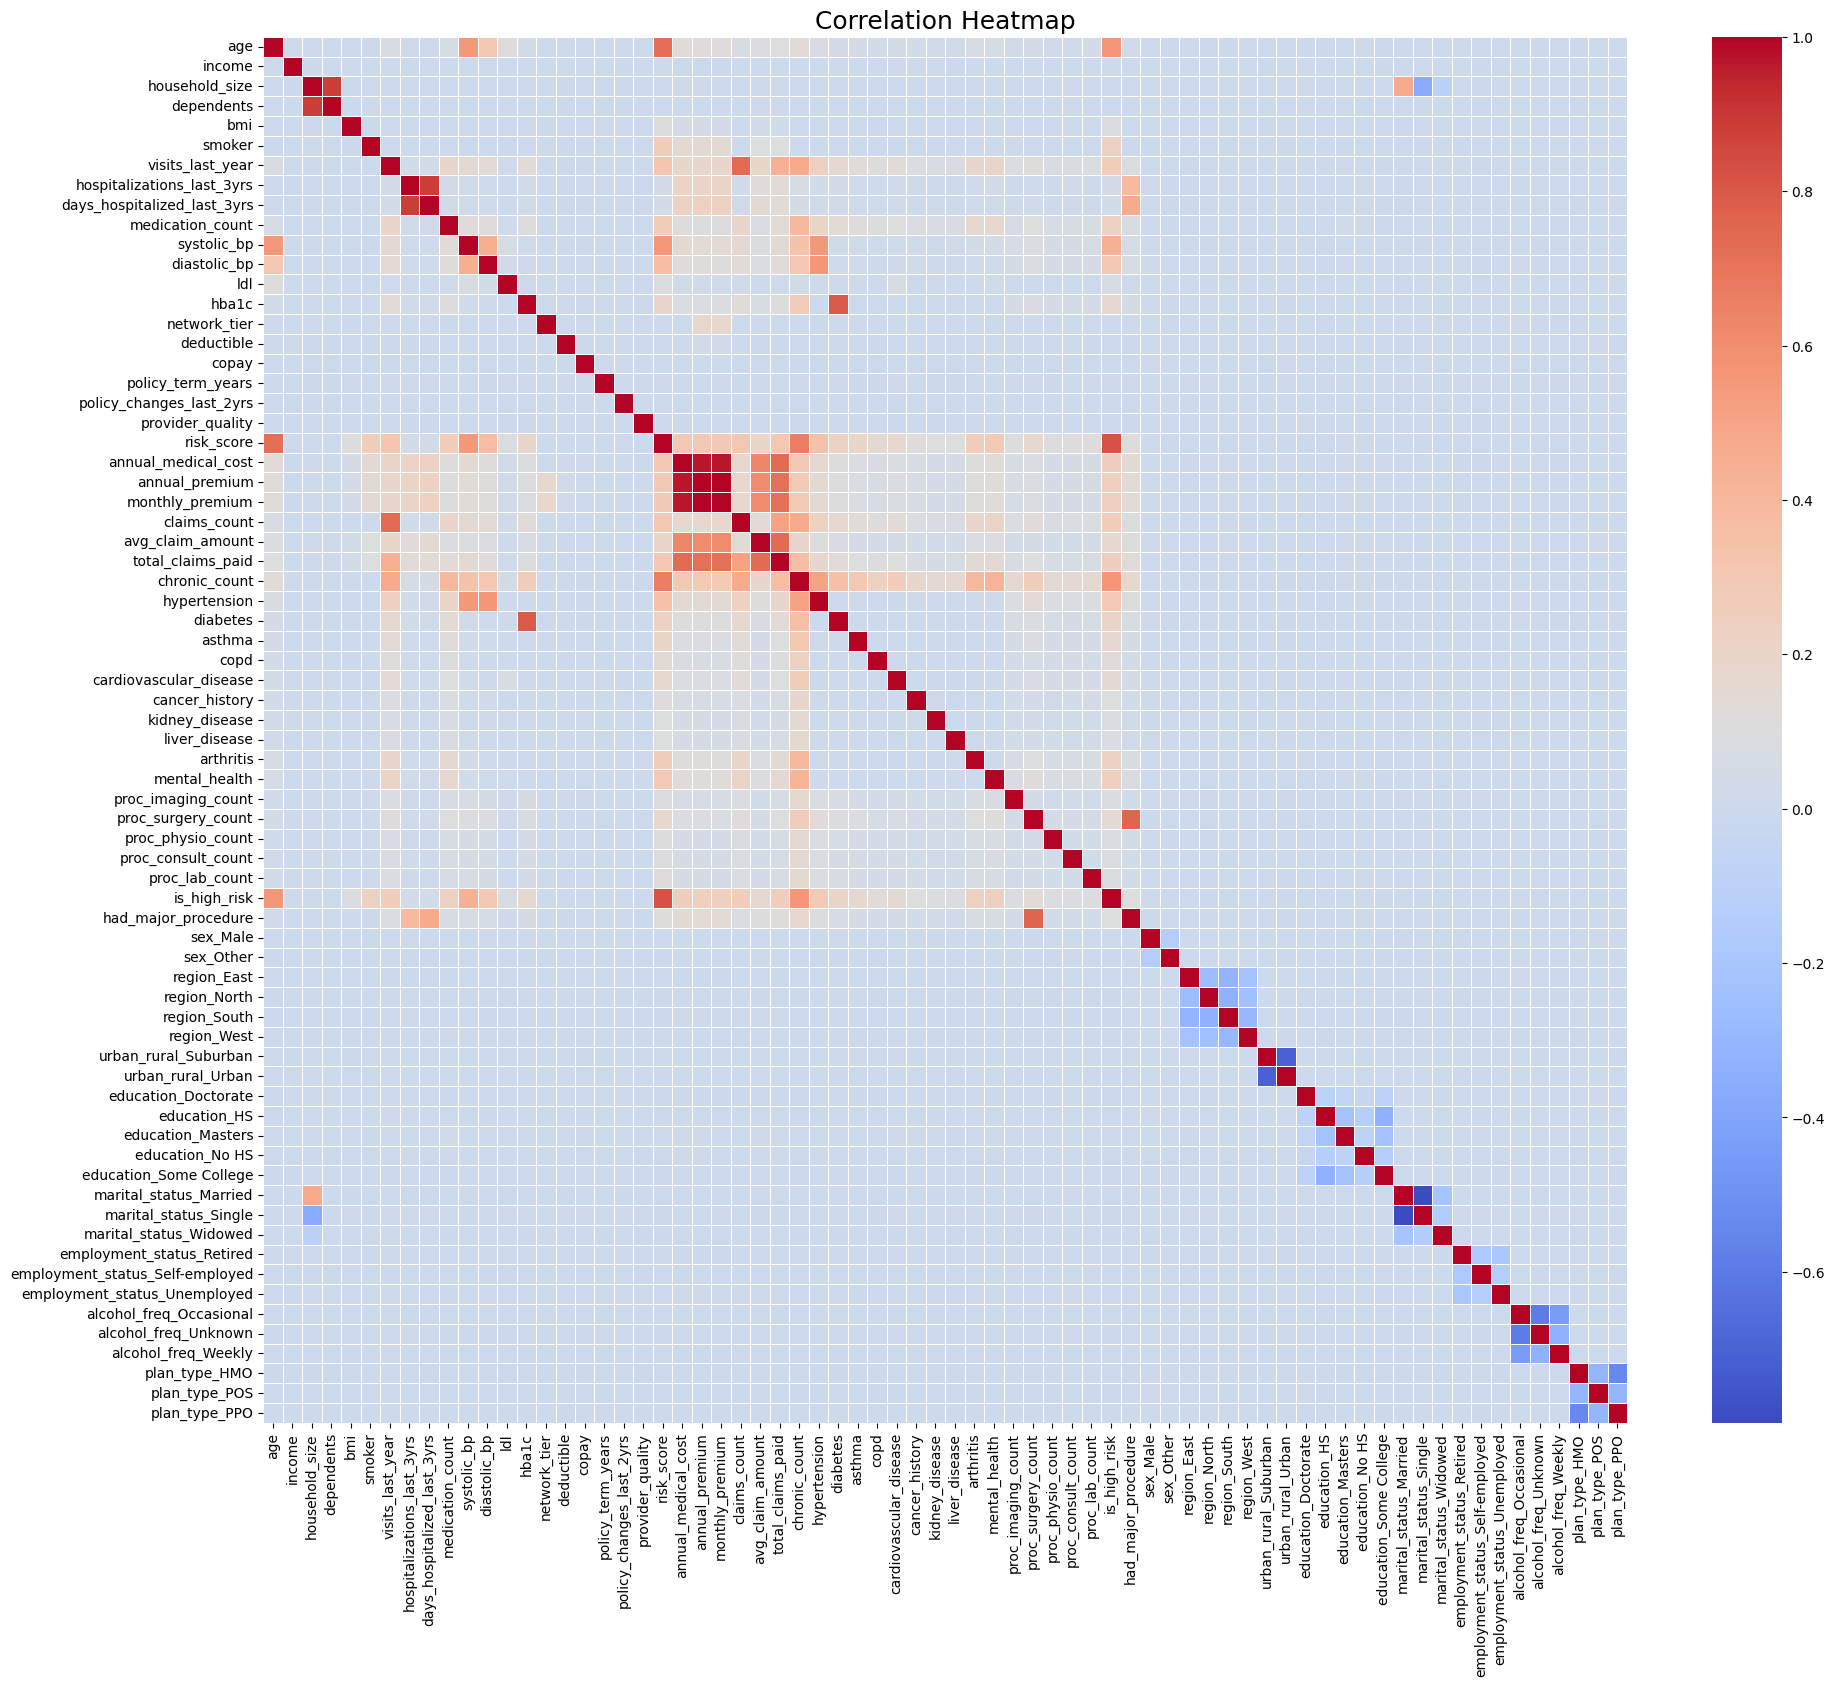

In [77]:

plt.figure(figsize=(22, 18))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

In [78]:
corr = df.corr(numeric_only=True)

corr["annual_medical_cost"].sort_values(ascending=False)

annual_medical_cost          1.000000
monthly_premium              0.965416
annual_premium               0.965415
total_claims_paid            0.739402
avg_claim_amount             0.632996
                               ...   
provider_quality            -0.003214
employment_status_Retired   -0.003341
region_East                 -0.004393
education_Doctorate         -0.005363
income                      -0.005974
Name: annual_medical_cost, Length: 70, dtype: float64

In [79]:
cols_to_drop = [
    "annual_premium",
    "monthly_premium",
    "total_claims_paid",
    "avg_claim_amount"
]

df.drop(columns=cols_to_drop, inplace=True)

In [80]:
corr = df.corr(numeric_only=True)

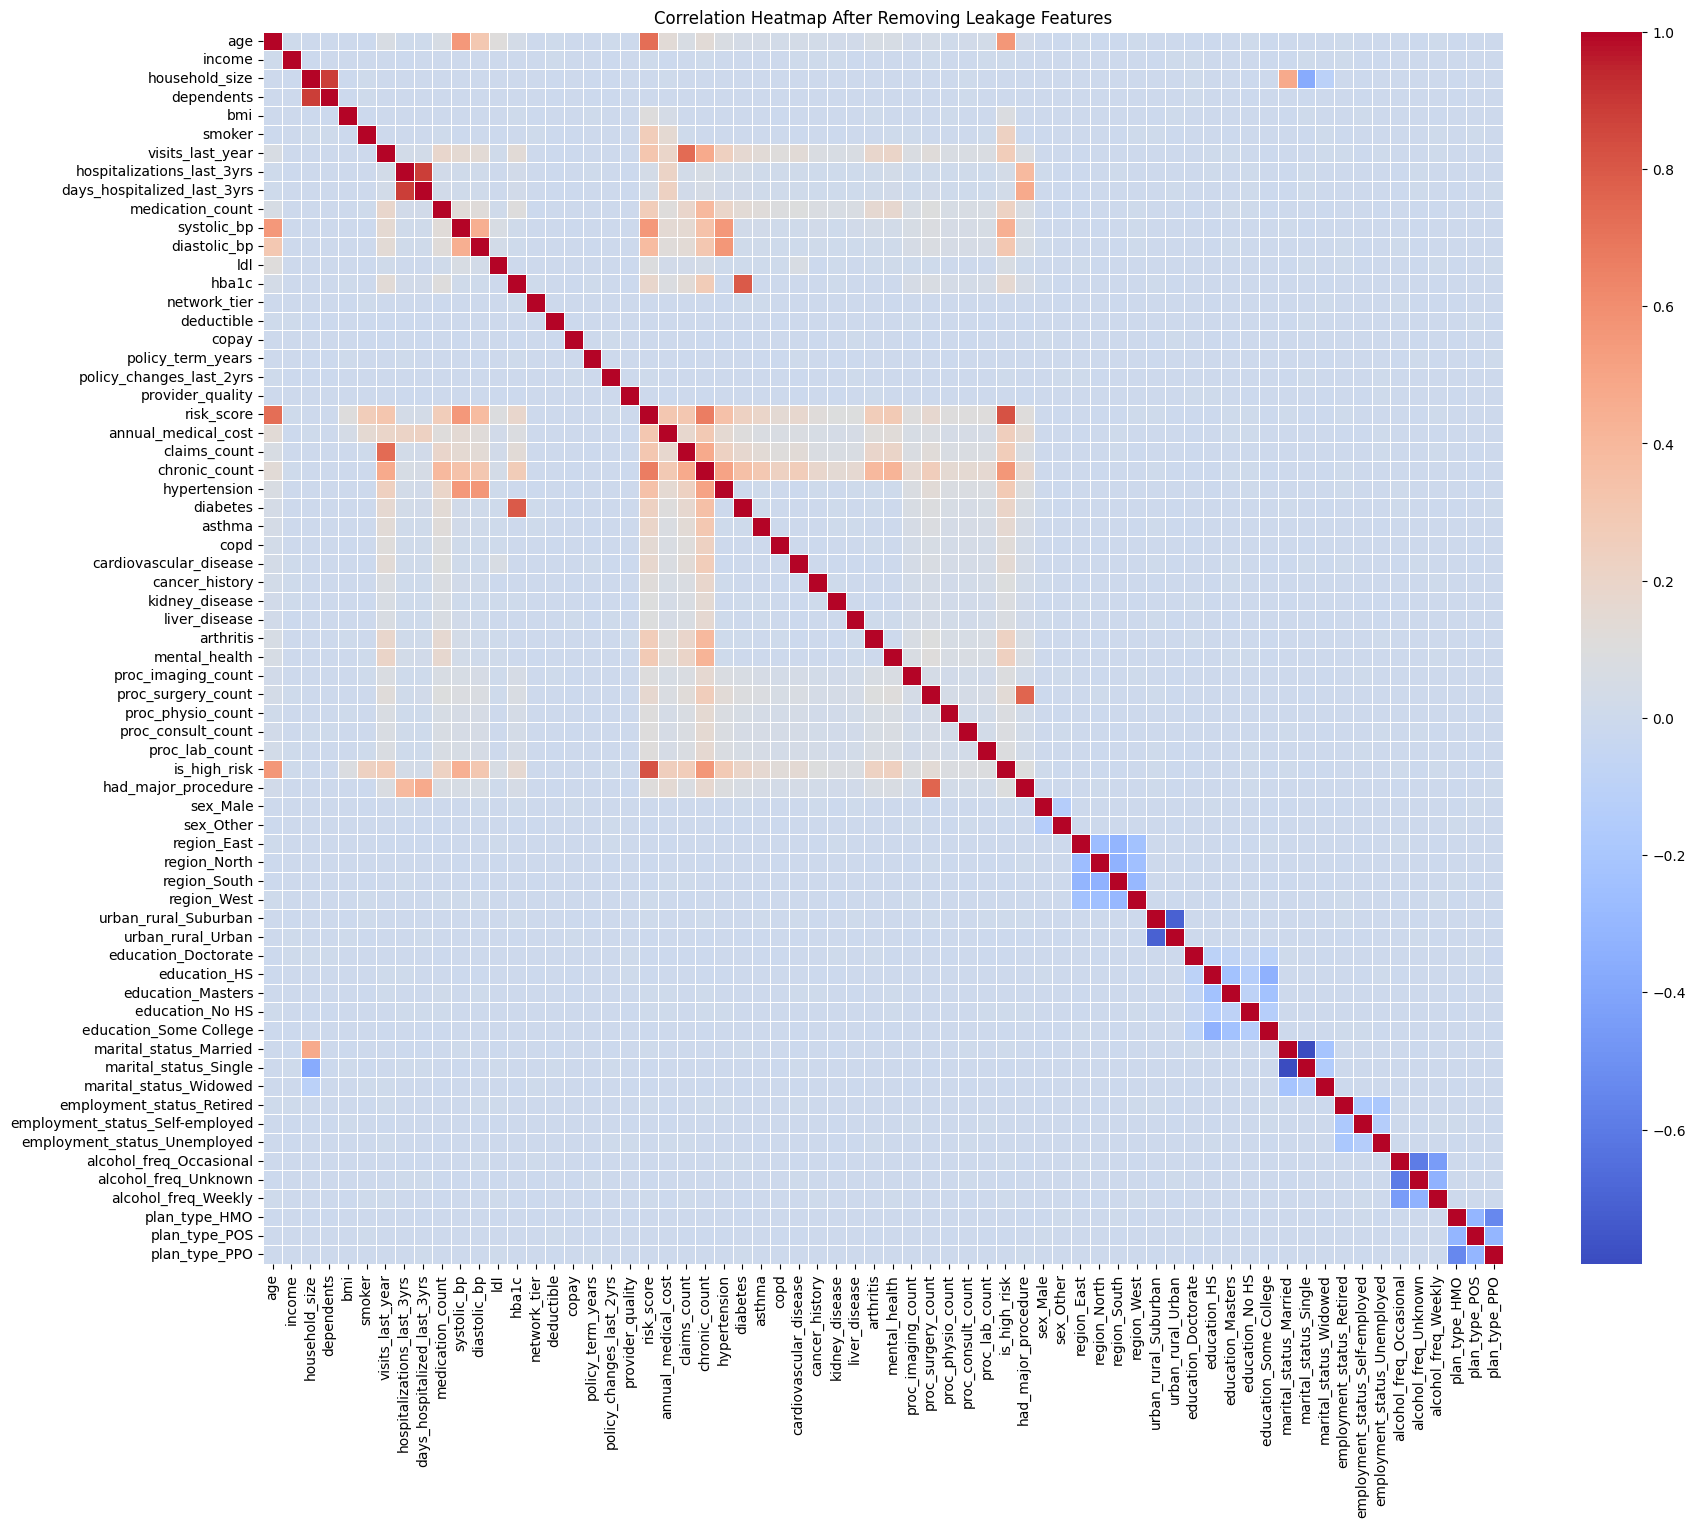

In [81]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap After Removing Leakage Features")
plt.show()

In [82]:
corr["annual_medical_cost"].sort_values(ascending=False).head(15)

annual_medical_cost            1.000000
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
smoker                         0.155642
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
Name: annual_medical_cost, dtype: float64